In [1]:
import torch
import cv2
import numpy as np
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

/opt/dlami/nvme/mitunet_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = "/opt/dlami/nvme/mitunet_weights/mitunet.pth"

In [3]:
aux_segformer = smp.Segformer(encoder_name="mit_b4", encoder_weights=None)
model = smp.Unet(
    encoder_name="mit_b4",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
# Transplant the encoder
model.encoder = aux_segformer.encoder

# 3. Load trained weights
state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

/tmp/ipykernel_10104/2368169390.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(WEIGHTS_PATH, map_location=DEVICE)


Unet(
  (encoder): MixVisionTransformerEncoder(
    (patch_embed1): OverlapPatchEmbed(
      (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed2): OverlapPatchEmbed(
      (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed3): OverlapPatchEmbed(
      (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
    (patch_embed4): OverlapPatchEmbed(
      (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (block1): Sequential(
      (0): Block(
        (norm1): LayerNorm((64,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (q): Linear(in_features=64

In [4]:
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

IMAGE_PATH = "../test_images/floor_plan_01.png"

# 5. Load and Preprocess Image
image = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

augmented = transform(image=image_rgb)
input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

In [5]:
with torch.no_grad():
    logits = model(input_tensor)
    print("Logits shape:", logits.shape)
    probs = torch.sigmoid(logits)
    print("Probabilities shape:", probs.shape)
    mask = (probs > 0.5).float()
    print("Mask shape:", mask.shape)

Logits shape: torch.Size([1, 1, 512, 512])
Probabilities shape: torch.Size([1, 1, 512, 512])
Mask shape: torch.Size([1, 1, 512, 512])


In [6]:
result_mask = mask.squeeze().cpu().numpy()

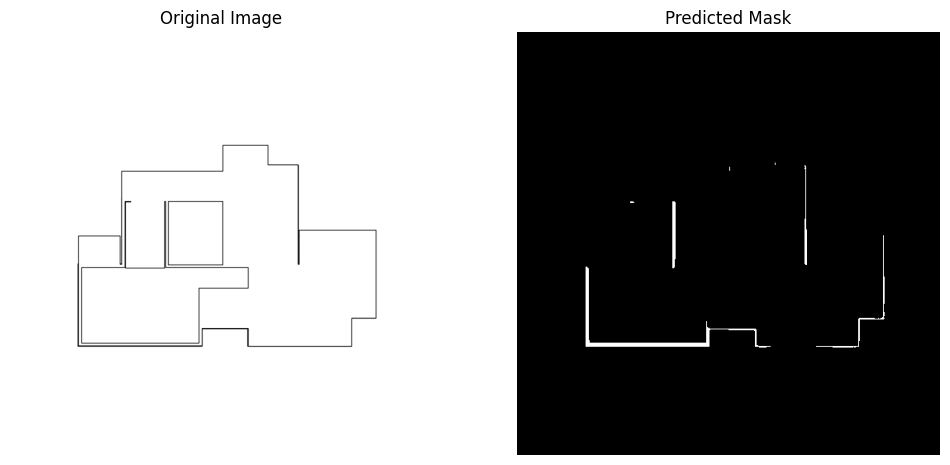

In [7]:
# plot the original image and the predicted mask
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(result_mask, cmap='gray')
plt.axis('off')
plt.show()

In [8]:
# write a function to test and then plot
def predict(img_path, show=True):
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image_rgb)
    input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float()

    result_mask = mask.squeeze().cpu().numpy()

    if show:
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title("Predicted Mask")
        plt.imshow(result_mask, cmap='gray')
        plt.axis('off')

        plt.show()

    return result_mask

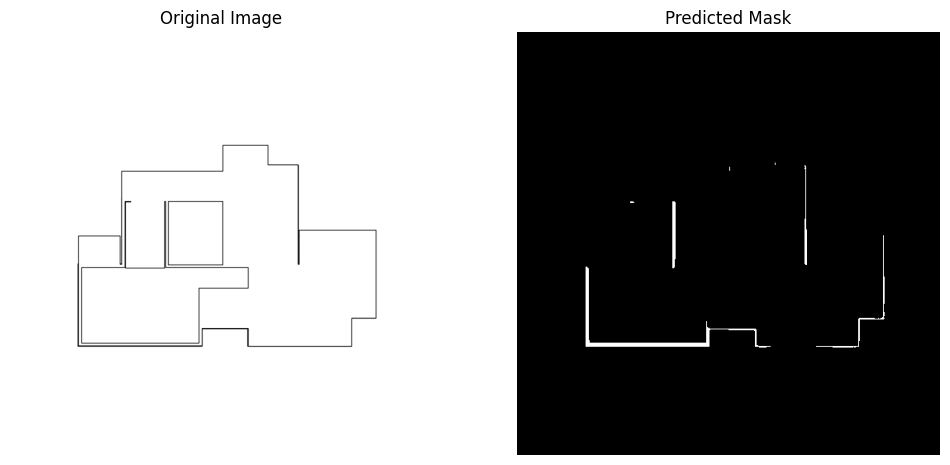

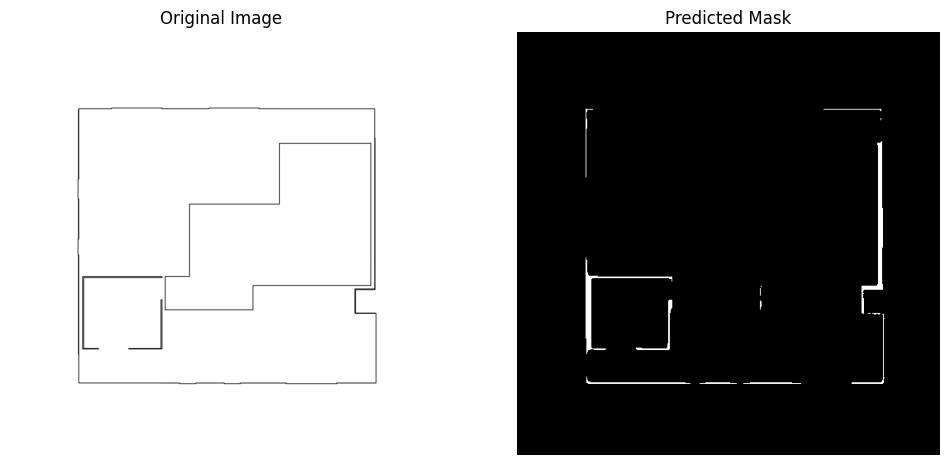

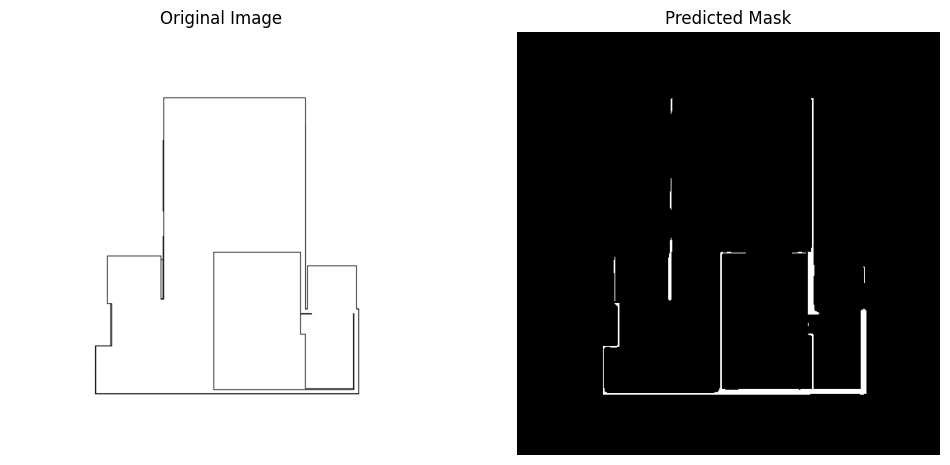

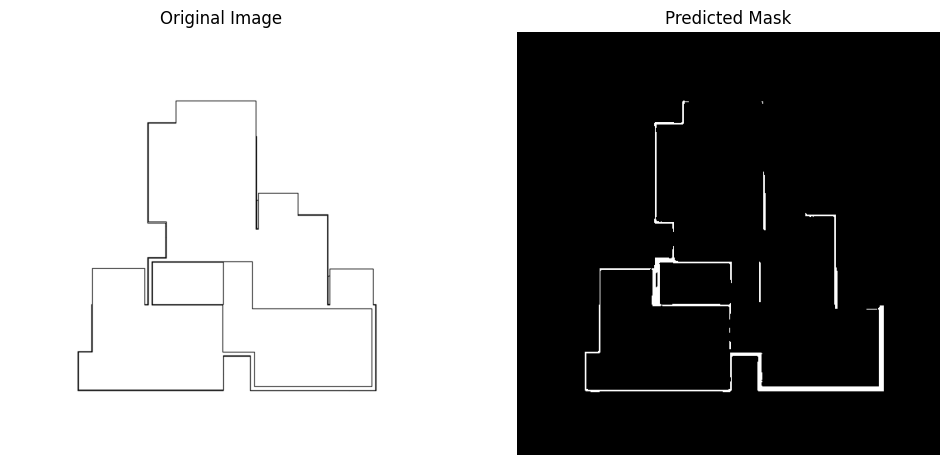

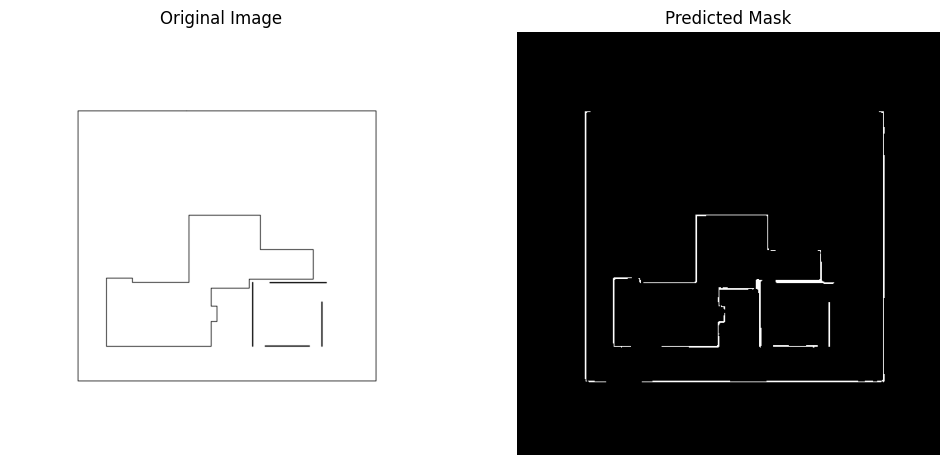

In [9]:
IMAGE_PATH = "../test_images"

for i in range(1, 6):
    img_path = f"{IMAGE_PATH}/floor_plan_0{i}.png"
    predict(img_path)

In [10]:
dataset_path = "/opt/dlami/nvme/mitunet_dataset/images"

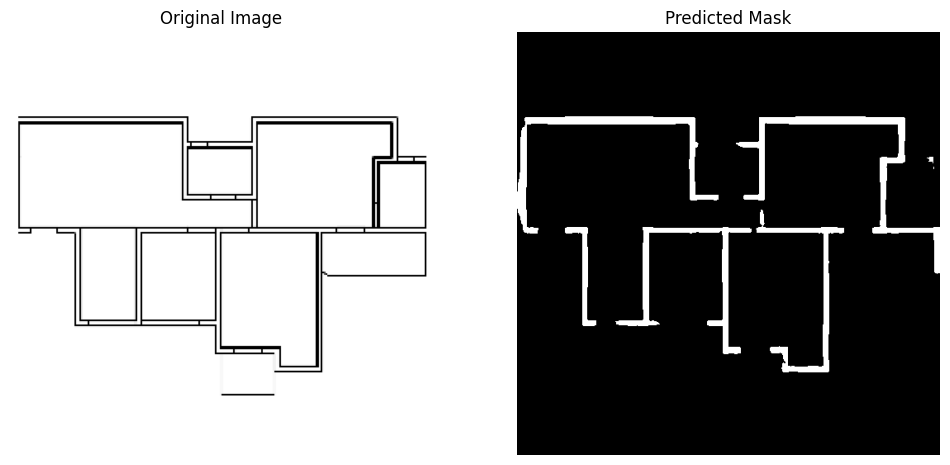

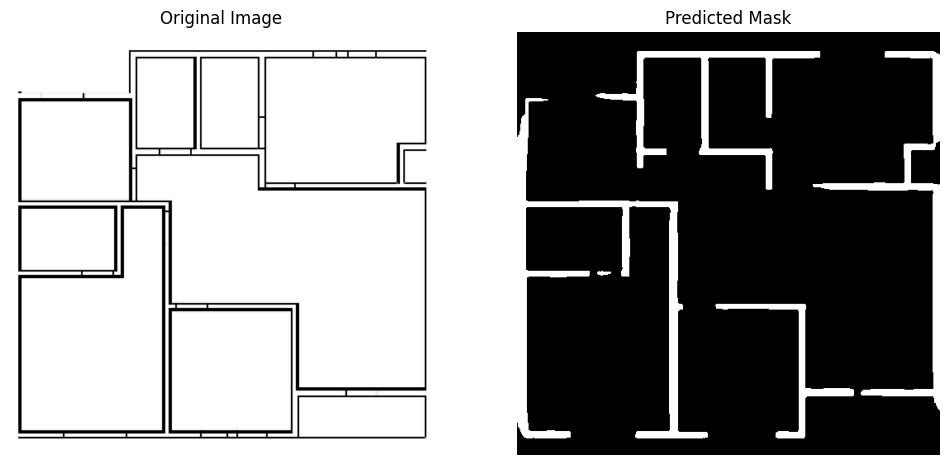

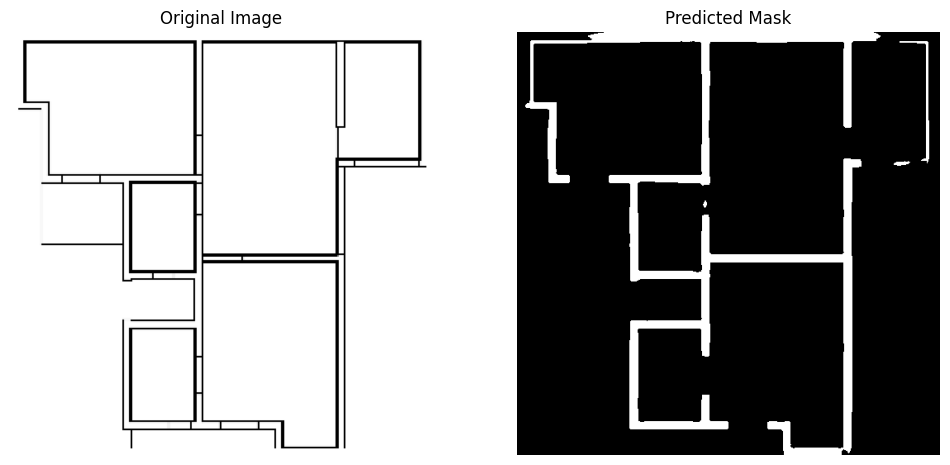

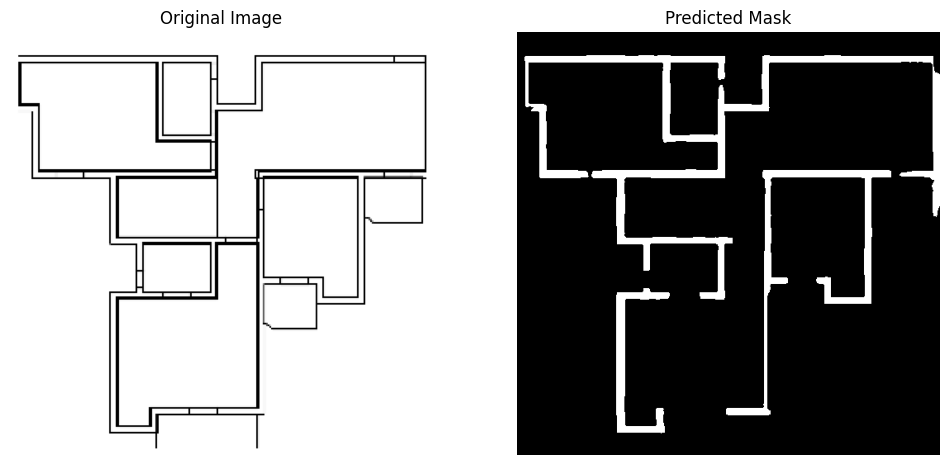

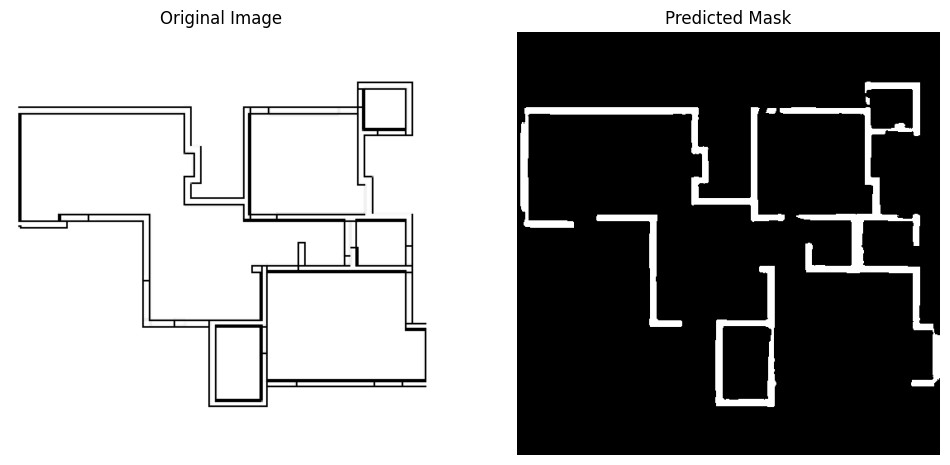

In [11]:
for i in range(5):
    img_path = f"{dataset_path}/{i:05d}.png"
    predict(img_path)

In [12]:
# write a function to test and then plot
def predict(img_path, mask_path=None, show=True):

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image_rgb)
    input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float()

    result_mask = mask.squeeze().cpu().numpy()

    # ---------------------------------
    # Load GT mask if provided
    # ---------------------------------
    gt_mask = None

    if mask_path is not None:
        gt_mask = cv2.imread(mask_path, 0)

        # wall only
        gt_mask = (gt_mask == 1).astype(np.uint8)

    # ---------------------------------
    # Plot
    # ---------------------------------
    if show:

        cols = 3 if gt_mask is not None else 2

        plt.figure(figsize=(18, 6))

        # Original image
        plt.subplot(1, cols, 1)
        plt.title("Original Image")
        plt.imshow(image_rgb)
        plt.axis('off')

        # Prediction
        plt.subplot(1, cols, 2)
        plt.title("Predicted Mask")
        plt.imshow(result_mask, cmap='gray')
        plt.axis('off')

        # GT mask
        if gt_mask is not None:
            plt.subplot(1, cols, 3)
            plt.title("GT Wall Mask")
            plt.imshow(gt_mask, cmap='gray')
            plt.axis('off')

        plt.show()

    return result_mask

  0%|          | 0/10 [00:00<?, ?it/s]

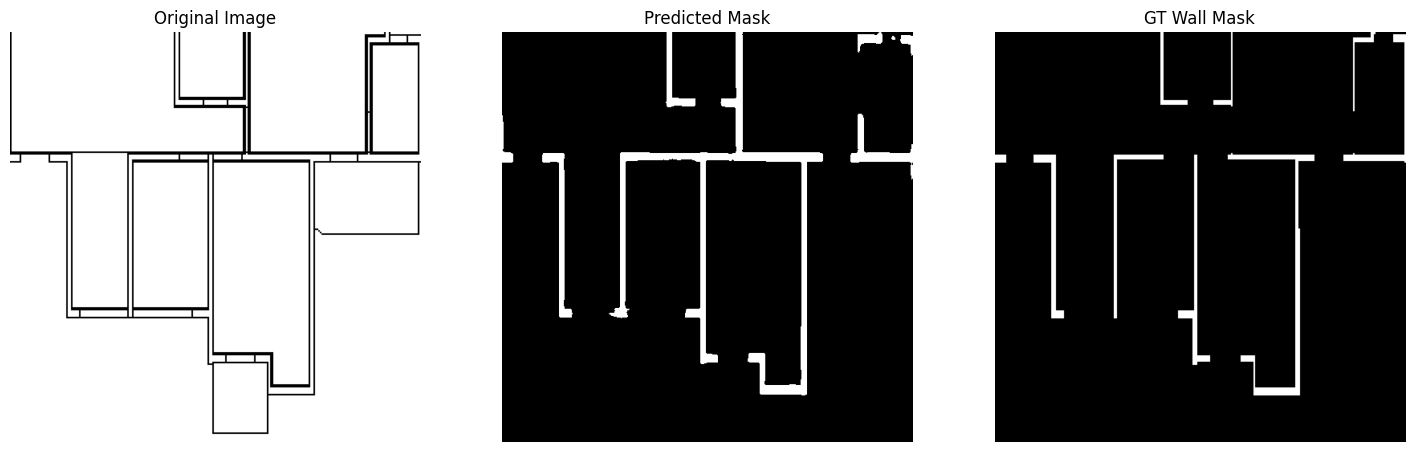

 10%|█         | 1/10 [00:00<00:02,  3.39it/s]

<class 'numpy.ndarray'>


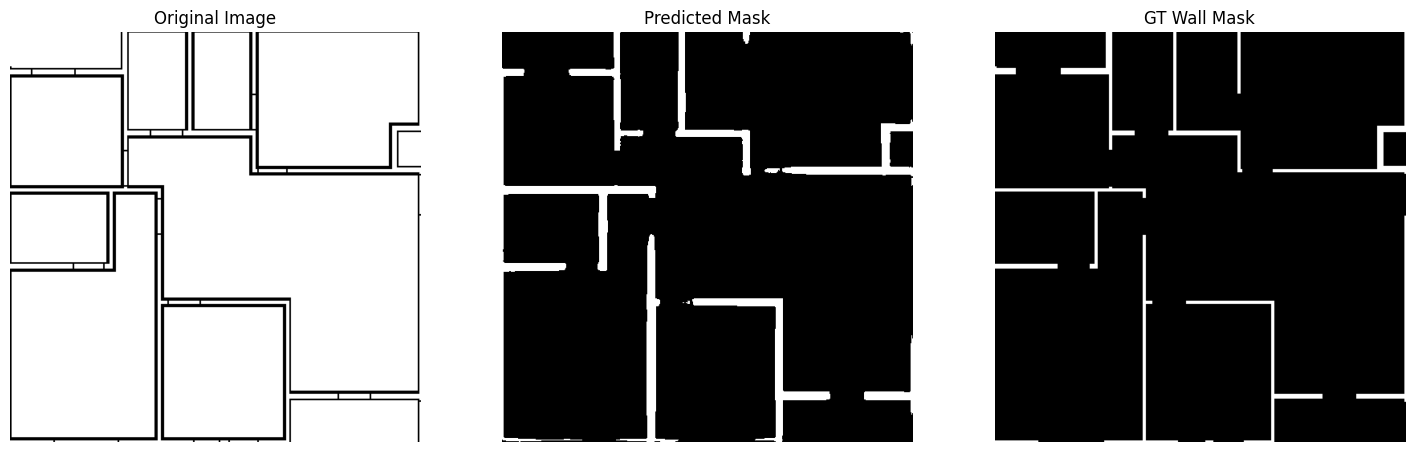

 20%|██        | 2/10 [00:00<00:02,  3.38it/s]

<class 'numpy.ndarray'>


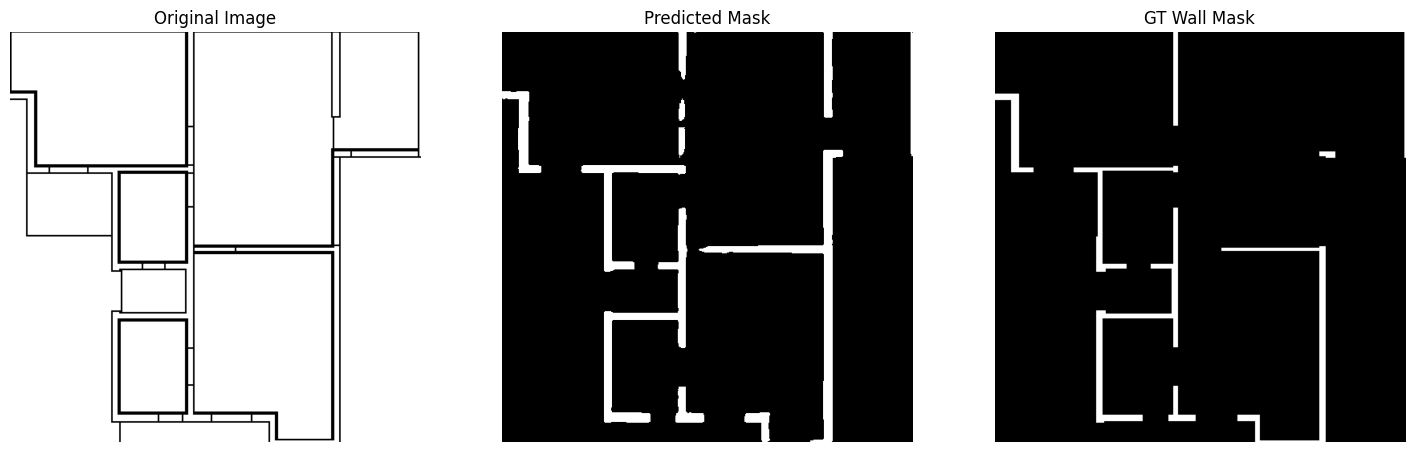

 30%|███       | 3/10 [00:00<00:02,  3.31it/s]

<class 'numpy.ndarray'>


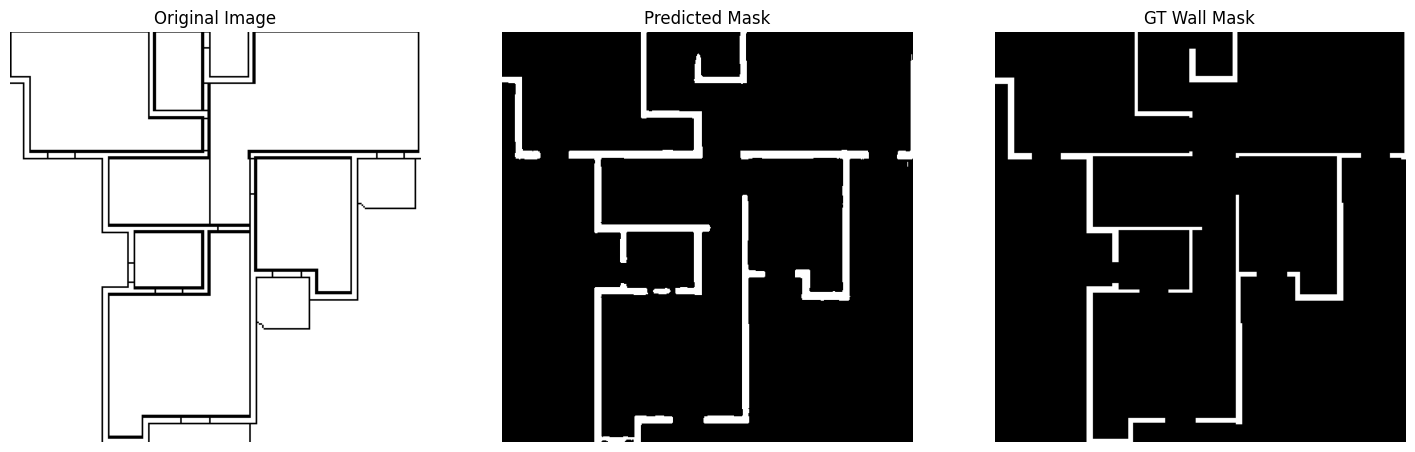

 40%|████      | 4/10 [00:01<00:01,  3.34it/s]

<class 'numpy.ndarray'>


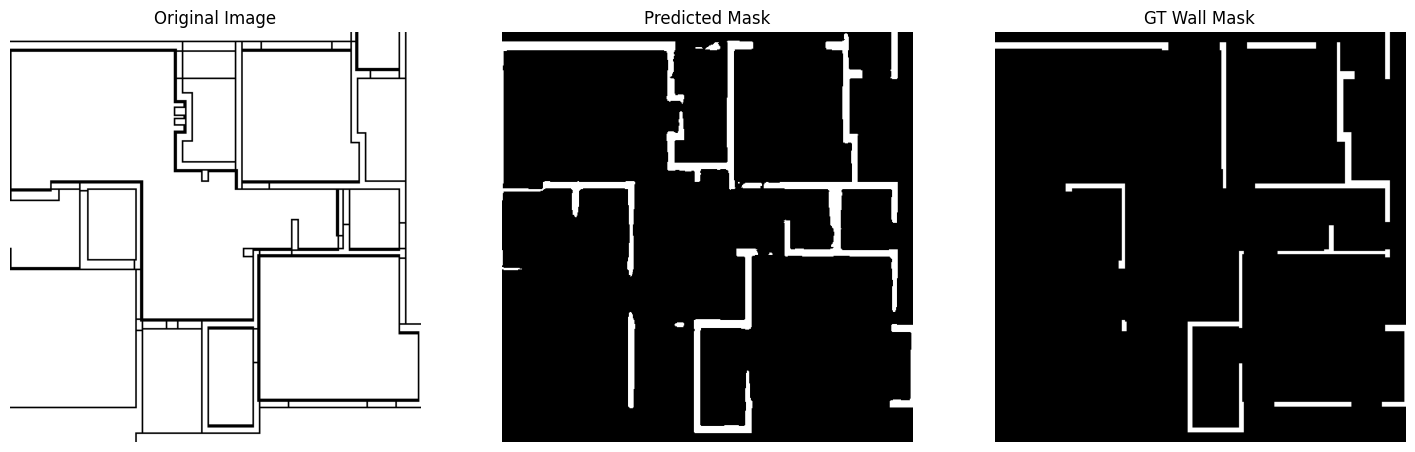

 50%|█████     | 5/10 [00:01<00:01,  2.56it/s]

<class 'numpy.ndarray'>


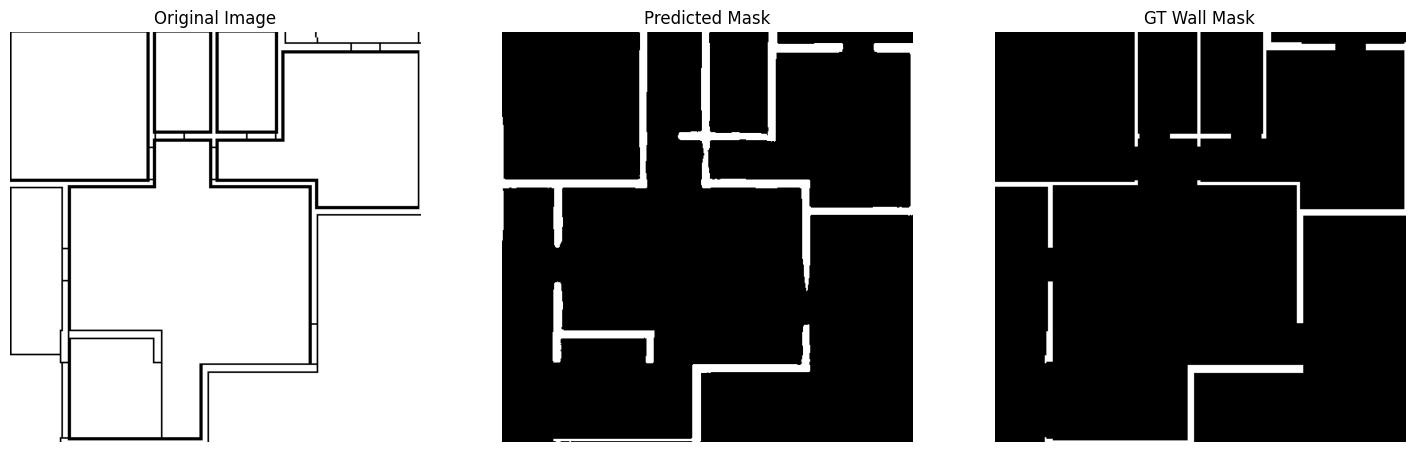

 60%|██████    | 6/10 [00:02<00:01,  2.83it/s]

<class 'numpy.ndarray'>


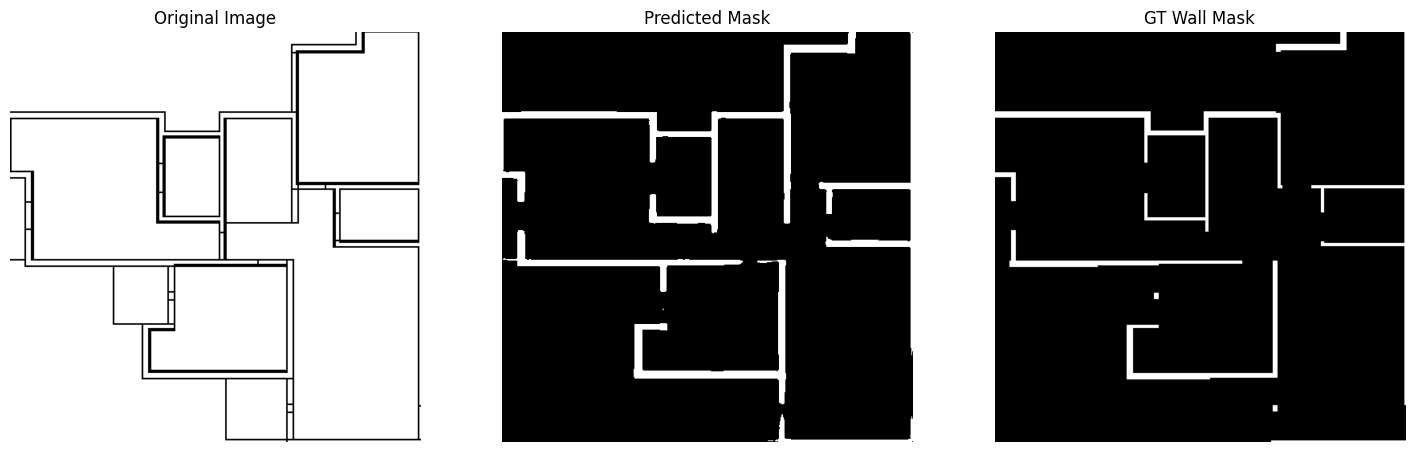

 70%|███████   | 7/10 [00:02<00:00,  3.01it/s]

<class 'numpy.ndarray'>


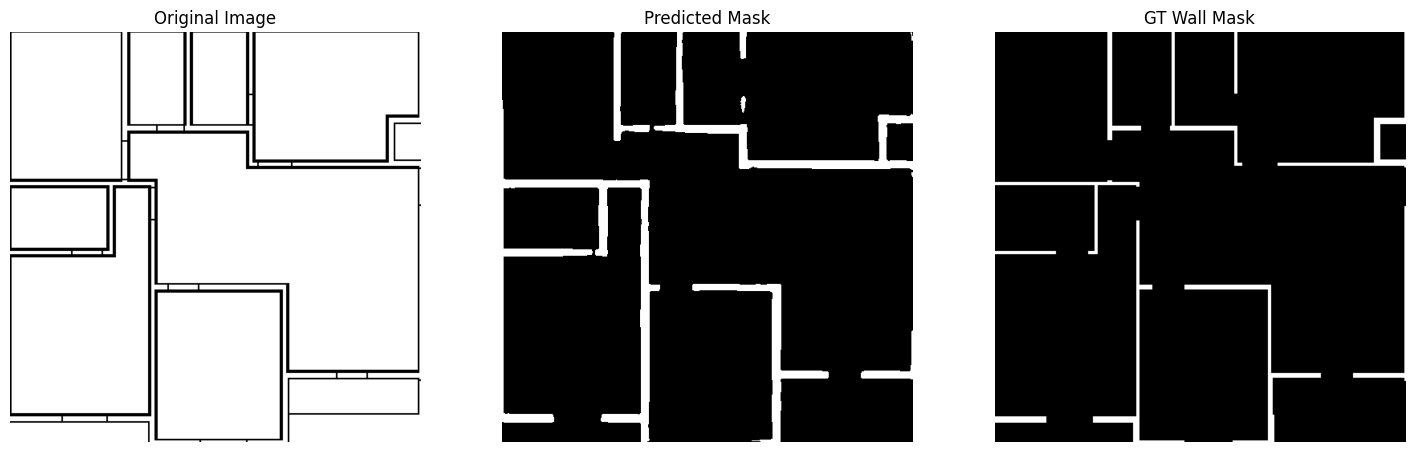

 80%|████████  | 8/10 [00:02<00:00,  3.12it/s]

<class 'numpy.ndarray'>


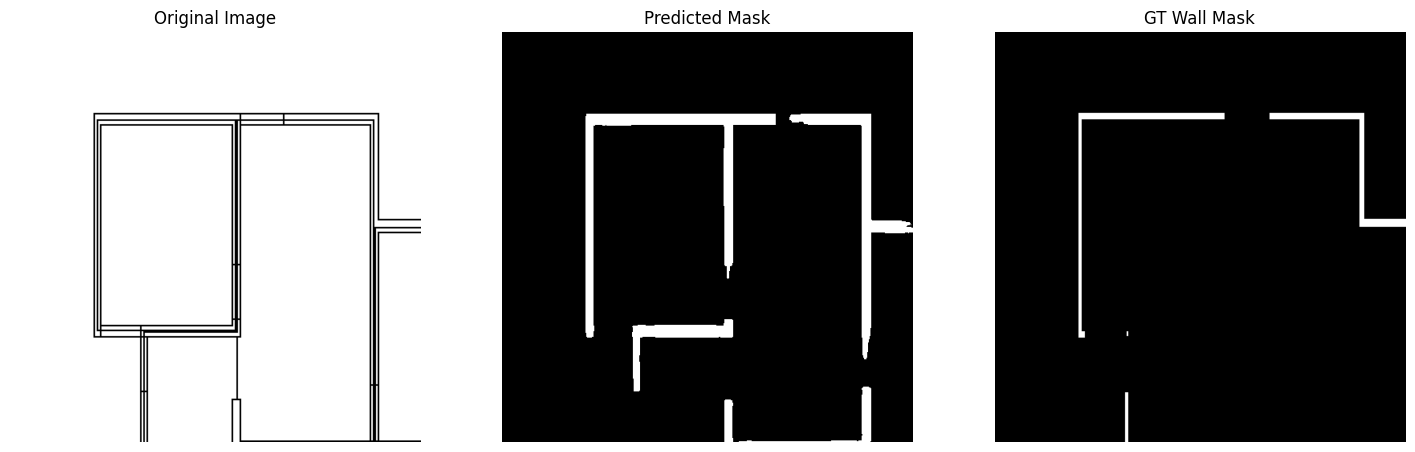

 90%|█████████ | 9/10 [00:02<00:00,  3.24it/s]

<class 'numpy.ndarray'>


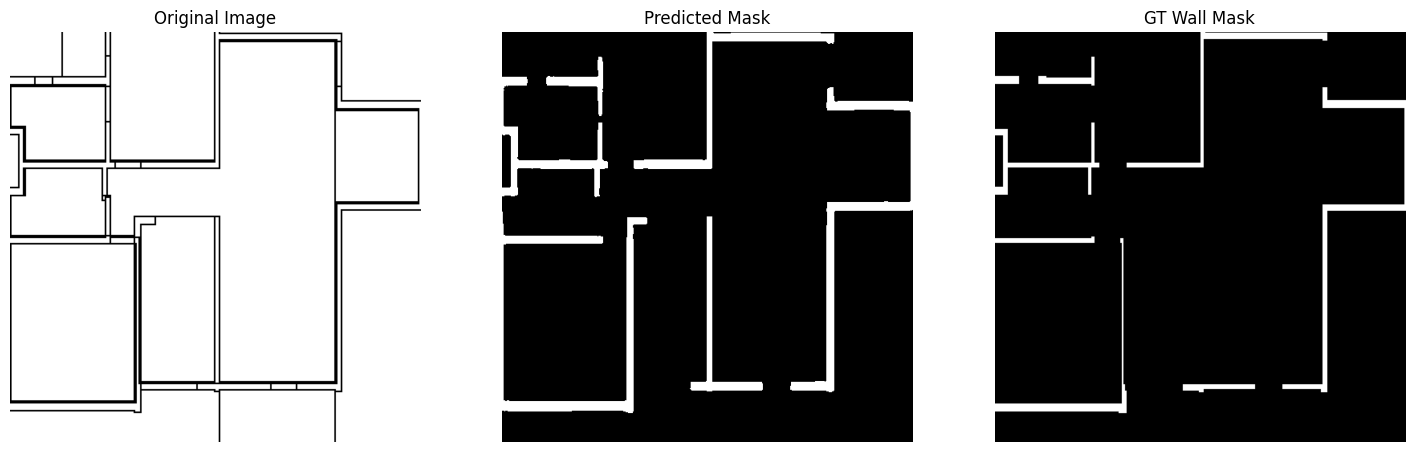

100%|██████████| 10/10 [00:03<00:00,  3.15it/s]

<class 'numpy.ndarray'>
mIoU : 0.4887612951365094
mAP  : 0.4707633813709299


In [16]:
import numpy as np
from sklearn.metrics import jaccard_score, average_precision_score
from tqdm import tqdm

ious = []
aps = []

dataset_path = "/opt/dlami/nvme/mitunet_dataset_1/images"
mask_path    = "/opt/dlami/nvme/mitunet_dataset_1/masks"

for i in tqdm(range(10)):

    # -----------------------------
    # Image path
    # -----------------------------
    img_path = f"{dataset_path}/{i:05d}.png"

    # -----------------------------
    # Ground truth mask
    # -----------------------------
    gt_mask = cv2.imread(
        f"{mask_path}/{i:05d}.png",
        0
    )

    # Wall class only
    gt_wall = (gt_mask == 1).astype(np.uint8)

    # -----------------------------
    # Prediction
    # -----------------------------
    pred_mask = predict(img_path, mask_path=f"{mask_path}/{i:05d}.png", show=True)

    print(type(pred_mask))

    # Binary prediction
    pred_wall = (pred_mask > 0).astype(np.uint8)
    # resize prediction to GT mask size
    pred_wall = cv2.resize(
        pred_wall.astype(np.uint8),
        (gt_wall.shape[1], gt_wall.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # -----------------------------
    # Flatten
    # -----------------------------
    gt   = gt_wall.flatten()
    pred = pred_wall.flatten()

    # -----------------------------
    # IoU
    # -----------------------------
    iou = jaccard_score(
        gt,
        pred,
        average="binary"
    )

    ious.append(iou)

    # -----------------------------
    # AP
    # -----------------------------
    ap = average_precision_score(
        gt,
        pred
    )

    aps.append(ap)

# -----------------------------
# Final metrics
# -----------------------------
print("mIoU :", np.mean(ious))
print("mAP  :", np.mean(aps))